**Import dependencies**

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
from pathlib import Path

**Read data**

In [2]:
tau_ext_data = pd.read_csv("tau_ext_test.csv")
tau_ext_deepc_data = pd.read_csv("tau_ext_test_kernel.csv")

# put 'label' as the row index
tau_ext_data = tau_ext_data.set_index("label")
tau_ext_deepc_data = tau_ext_deepc_data.set_index("label")

# keep only the time columns (they look like t0.0, t0.1, ..., etc.)
time_cols = [c for c in tau_ext_data.columns if c.startswith("t")]
time_cols_deepc = [c for c in tau_ext_deepc_data.columns if c.startswith("t")]

# numeric sort for rows like 'tau_cmd_0', 'tau_cmd_1', ...
def row_sort_key(s):
    m = re.search(r"_(\d+)$", s)
    return int(m.group(1)) if m else 10**9

# select and sort the tau_ext
tau_ext = sorted([r for r in tau_ext_data.index if r.startswith("tau_ext")], key=row_sort_key)
tau_ext_deepc = sorted([r for r in tau_ext_deepc_data.index if r.startswith("tau_ext")], key=row_sort_key)

tau_ext = tau_ext_data.loc[tau_ext, time_cols].to_numpy()
tau_ext_deepc = tau_ext_deepc_data.loc[tau_ext_deepc, time_cols_deepc].to_numpy()

print(tau_ext.shape)
print(tau_ext_deepc.shape)

print("RMS tau_ext:", np.sqrt(np.mean(tau_ext**2)))
print("RMS tau_ext_deepc:", np.sqrt(np.mean(tau_ext_deepc**2)))

(7, 14127)
(7, 14127)
RMS tau_ext: 0.5176756331864688
RMS tau_ext_deepc: 0.4870122730122948


**Plot tau_ext for each joint**

In [13]:
save_dir = Path.cwd()
n_rows = 7

# Compare only the overlapping portion.
T = min(tau_ext.shape[1], tau_ext_deepc.shape[1])

# time vector in seconds
time = np.arange(T) / 1000.0  # seconds

for i in range(n_rows):
    fig, ax = plt.subplots(figsize=(6, 3), dpi=150)

    ax.plot(time, tau_ext[i, :T], label="Joint_Impedance", color="blue", linewidth=1.2)
    ax.plot(time, tau_ext_deepc[i, :T], label="Kernel_DeePC", color="orange", linewidth=1.2)

    ax.set_title(f"Friction in joint {i+1}")
    ax.set_xlabel("Time [s]")
    ax.set_ylabel("Torque [Nm]")
    ax.legend()
    ax.grid(True, alpha=0.3)

    out_path = save_dir / f"friction_joint_{i+1}.pdf"
    fig.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.close(fig)

NameError: name 'tau_ext' is not defined

**Check prediction quality**

In [14]:
# Load data
data = pd.read_csv("tau_ext_test_kernel.csv")

# put 'label' as the row index
data = data.set_index("label")

# keep only the time columns (they look like t0.0, t0.1, ..., etc.)
time_cols = [c for c in data.columns if c.startswith("t")]

# numeric sort for rows like 'tau_cmd_0', 'tau_cmd_1', ...
def row_sort_key(s):
    m = re.search(r"_(\d+)$", s)
    return int(m.group(1)) if m else 10**9

# select and sort the commanded torques (u) and external torques (y)
tau_ext_rows = sorted([r for r in data.index if r.startswith("tau_ext")], key=row_sort_key)
prediction_rows = sorted([r for r in data.index if r.startswith("friction_pred")], key=row_sort_key)
# build arrays (first column is just 0.0)
tau_ext_full = data.loc[tau_ext_rows, time_cols].to_numpy().T
prediction_full = data.loc[prediction_rows, time_cols].to_numpy().T

print("tau_ext_full shape:", tau_ext_full.shape)
print("prediction_full shape:", prediction_full.shape)

tau_ext_full shape: (14125, 7)
prediction_full shape: (14125, 7)


**Plot predictions**

Joint 0: RMSE = 0.0616 Nm
Joint 1: RMSE = 0.0396 Nm
Joint 2: RMSE = 0.0285 Nm
Joint 3: RMSE = 0.0261 Nm
Joint 4: RMSE = 0.0133 Nm
Joint 5: RMSE = 0.0225 Nm
Joint 6: RMSE = 0.0065 Nm


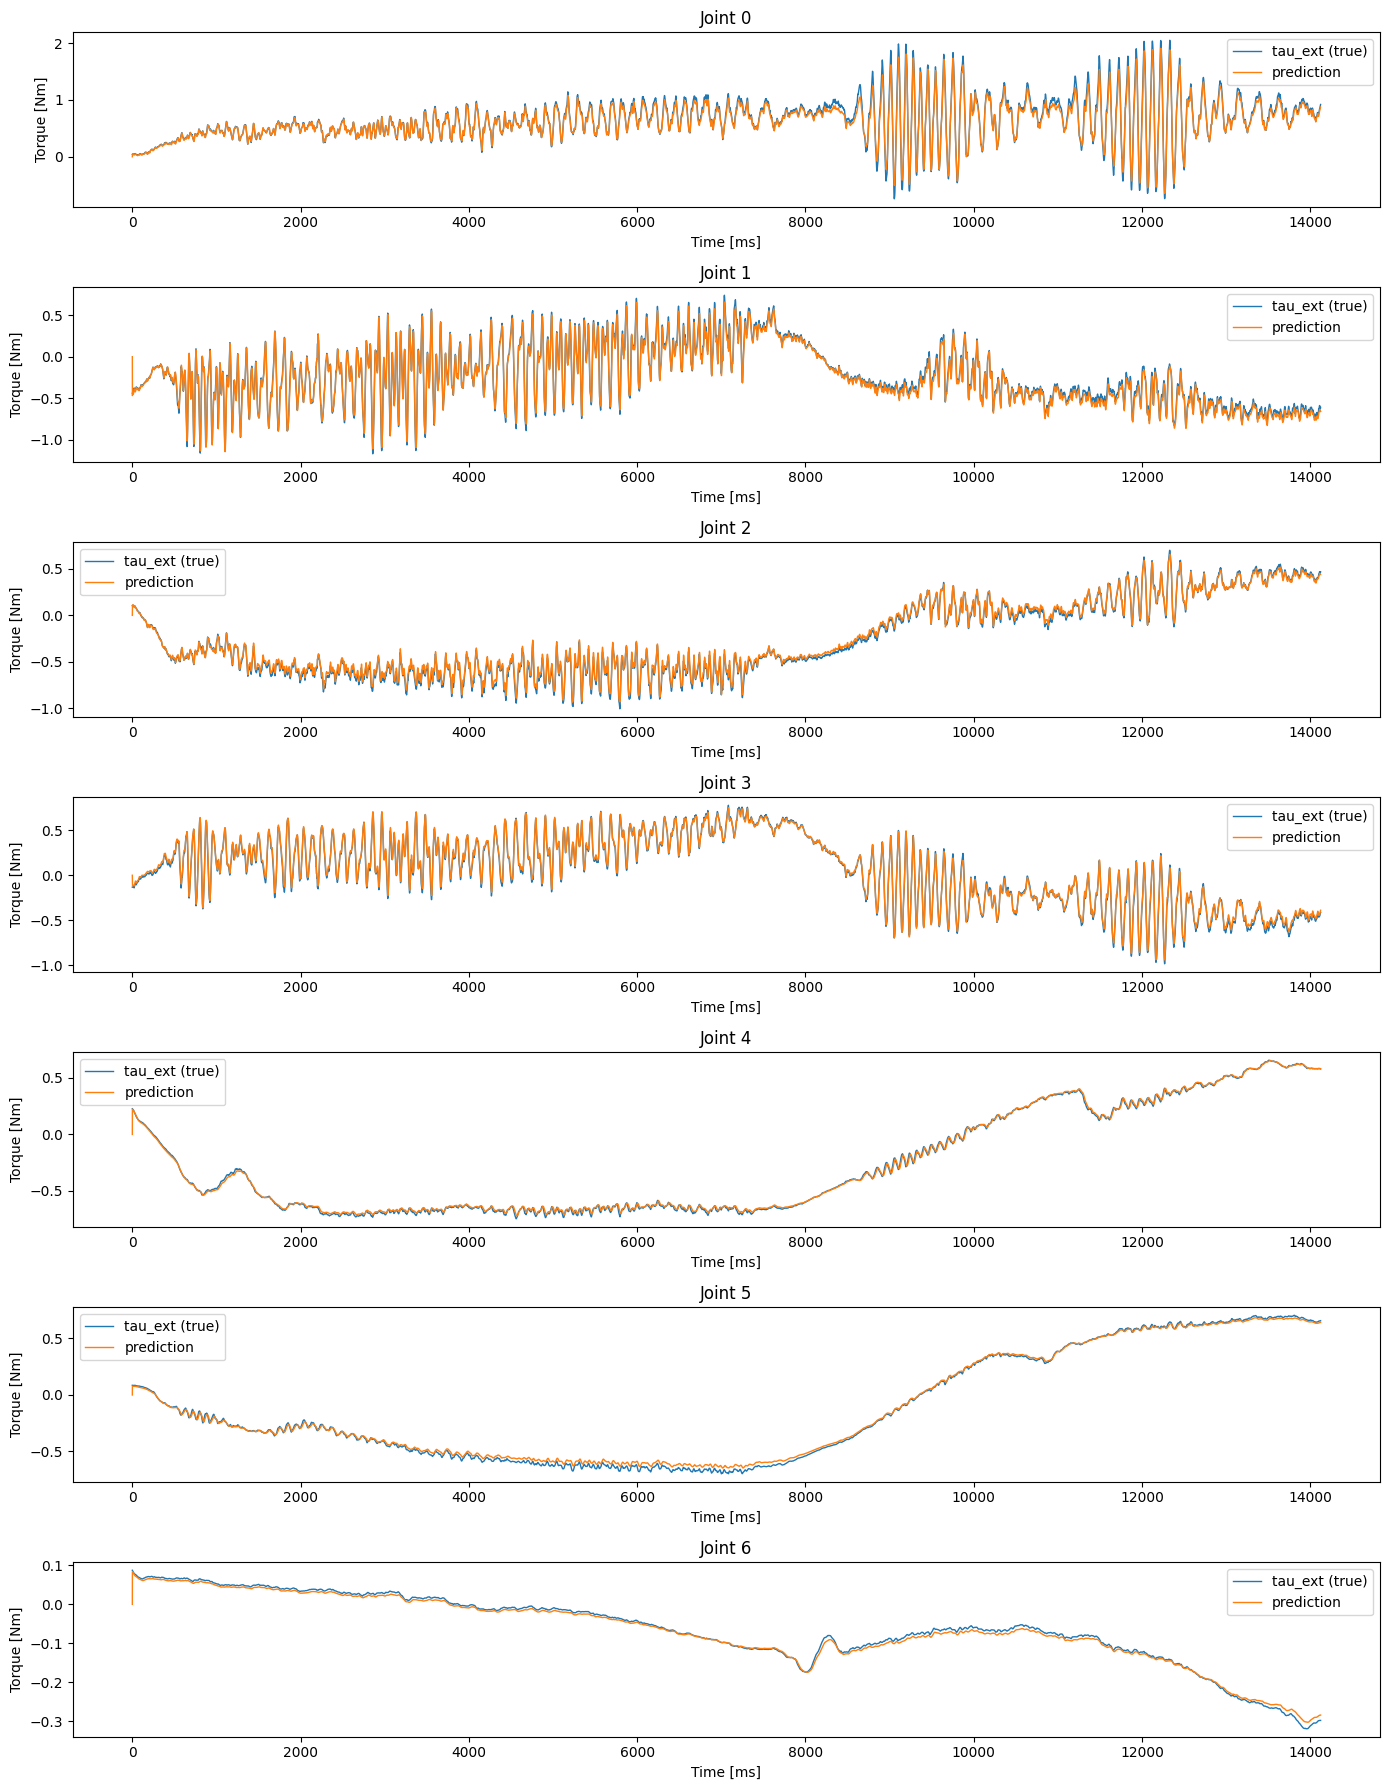

In [15]:
num_joints = tau_ext_full.shape[1]

plt.figure(figsize=(14, 18))

for i in range(num_joints):

    err = tau_ext_full[:, i] - prediction_full[:, i]
    rmse = np.sqrt(np.mean(err**2))
    print(f"Joint {i}: RMSE = {rmse:.4f} Nm")
    
    plt.subplot(num_joints, 1, i + 1)
    plt.plot(tau_ext_full[:, i], label="tau_ext (true)", linewidth=1.0)
    plt.plot(prediction_full[:, i], label="prediction", linewidth=1.0)
    plt.title(f"Joint {i}")
    plt.xlabel("Time [ms]")
    plt.ylabel("Torque [Nm]")
    plt.legend()

plt.tight_layout()
plt.show()

**Load residuals**

In [ ]:
# Load data
data = pd.read_csv("tau_ext_test_kernel.csv")

# put 'label' as the row index
data = data.set_index("label")

# keep only the time columns (they look like t0.0, t0.1, ..., etc.)
time_cols = [c for c in data.columns if c.startswith("t")]

# numeric sort for rows like 'tau_cmd_0', 'tau_cmd_1', ...
def row_sort_key(s):
    m = re.search(r"_(\d+)$", s)
    return int(m.group(1)) if m else 10**9

# select and sort the commanded torques (u) and external torques (y)
tau_ext_rows = sorted([r for r in data.index if r.startswith("tau_ext")], key=row_sort_key)
residuals_rows = sorted([r for r in data.index if r.startswith("tau_residual")], key=row_sort_key)
# build arrays (first column is just 0.0)
tau_ext_full = data.loc[tau_ext_rows, time_cols].to_numpy().T
residuals_full = data.loc[residuals_rows, time_cols].to_numpy().T

print("tau_ext_full shape:", tau_ext_full.shape)
print("residuals_full shape:", residuals_full.shape)

tau_ext_full shape: (14127, 7)
residuals_full shape: (14127, 7)


**PLot residuals vs tau_ext**

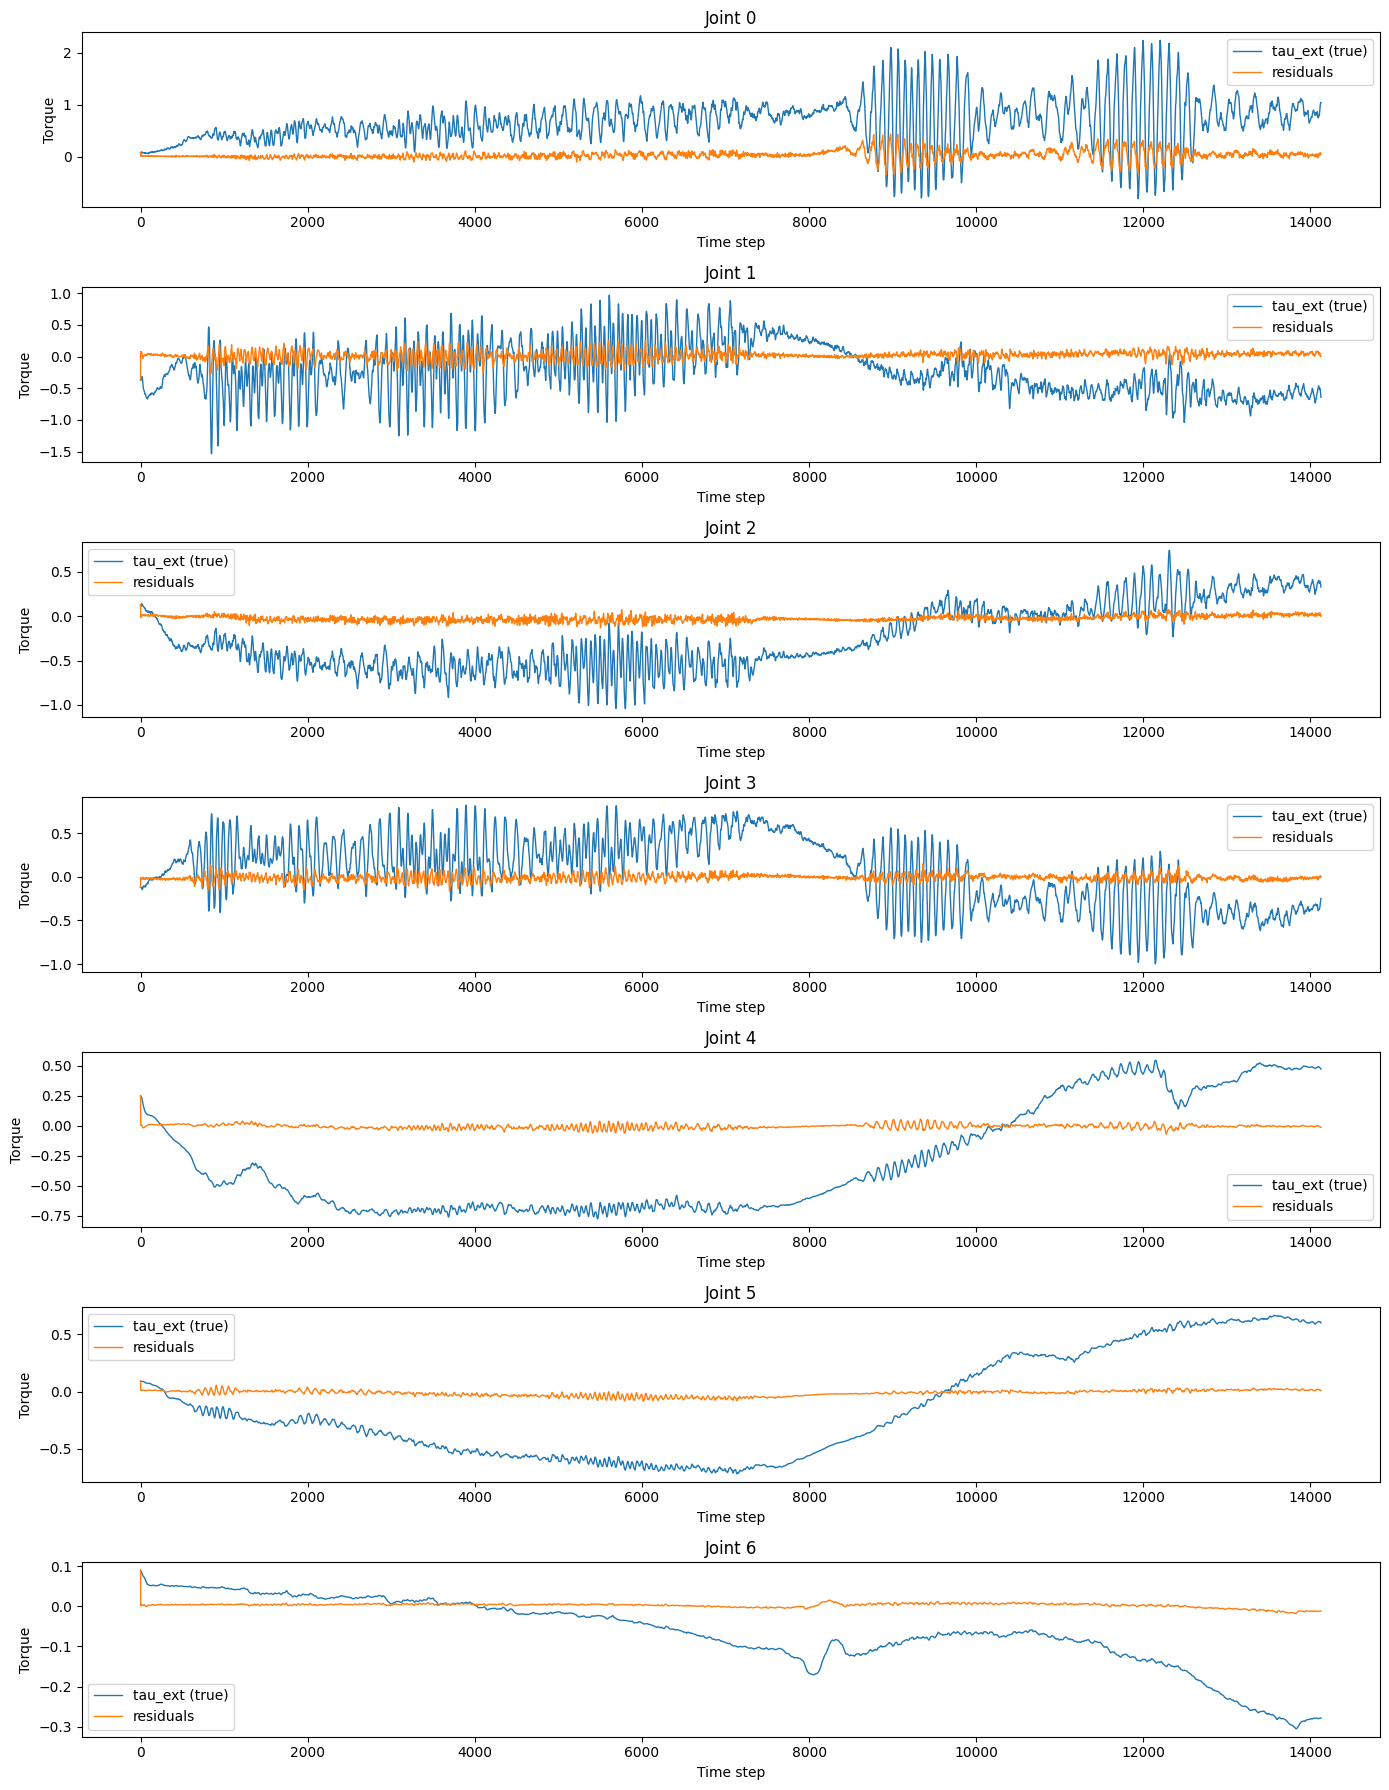

In [72]:
num_joints = tau_ext_full.shape[1]

plt.figure(figsize=(14, 18))

for i in range(num_joints):
    plt.subplot(num_joints, 1, i + 1)
    plt.plot(tau_ext_full[:, i], label="tau_ext (true)", linewidth=1.0)
    plt.plot(residuals_full[:, i], label="residuals", linewidth=1.0)
    plt.title(f"Joint {i}")
    plt.xlabel("Time step")
    plt.ylabel("Torque")
    plt.legend()

plt.tight_layout()
plt.show()

**Load joint positions**

In [34]:
# Load data
data = pd.read_csv("tau_ext_test.csv")
kernel_data = pd.read_csv("tau_ext_test_kernel.csv")

# put 'label' as the row index
data = data.set_index("label")
kernel_data = kernel_data.set_index("label")

# keep only the time columns (they look like t0.0, t0.1, ..., etc.)
time_cols = [c for c in data.columns if c.startswith("t")]
time_cols_kernel = [c for c in kernel_data.columns if c.startswith("t")]

# numeric sort for rows like 'tau_cmd_0', 'tau_cmd_1', ...
def row_sort_key(s):
    m = re.search(r"_(\d+)$", s)
    return int(m.group(1)) if m else 10**9

# select and sort the commanded torques (u) and external torques (y)
q_des_rows = sorted([r for r in kernel_data.index if r.startswith("q_des")], key=row_sort_key)
q_curr_rows = sorted([r for r in data.index if r.startswith("q_curr")], key=row_sort_key)
q_curr_kernel_rows = sorted([r for r in kernel_data.index if r.startswith("q_curr")], key=row_sort_key)

# build arrays (first column is just 0.0)
q_des = kernel_data.loc[q_des_rows, time_cols_kernel].to_numpy().T
q_curr = data.loc[q_curr_rows, time_cols].to_numpy().T
q_curr_kernel = kernel_data.loc[q_curr_kernel_rows, time_cols_kernel].to_numpy().T

print("q_des shape:", q_des.shape)
print("q_curr shape:", q_curr.shape)
print("q_curr_kernel shape:", q_curr_kernel.shape)

q_des shape: (14127, 7)
q_curr shape: (14127, 7)
q_curr_kernel shape: (14127, 7)


**Plot tracking quality**

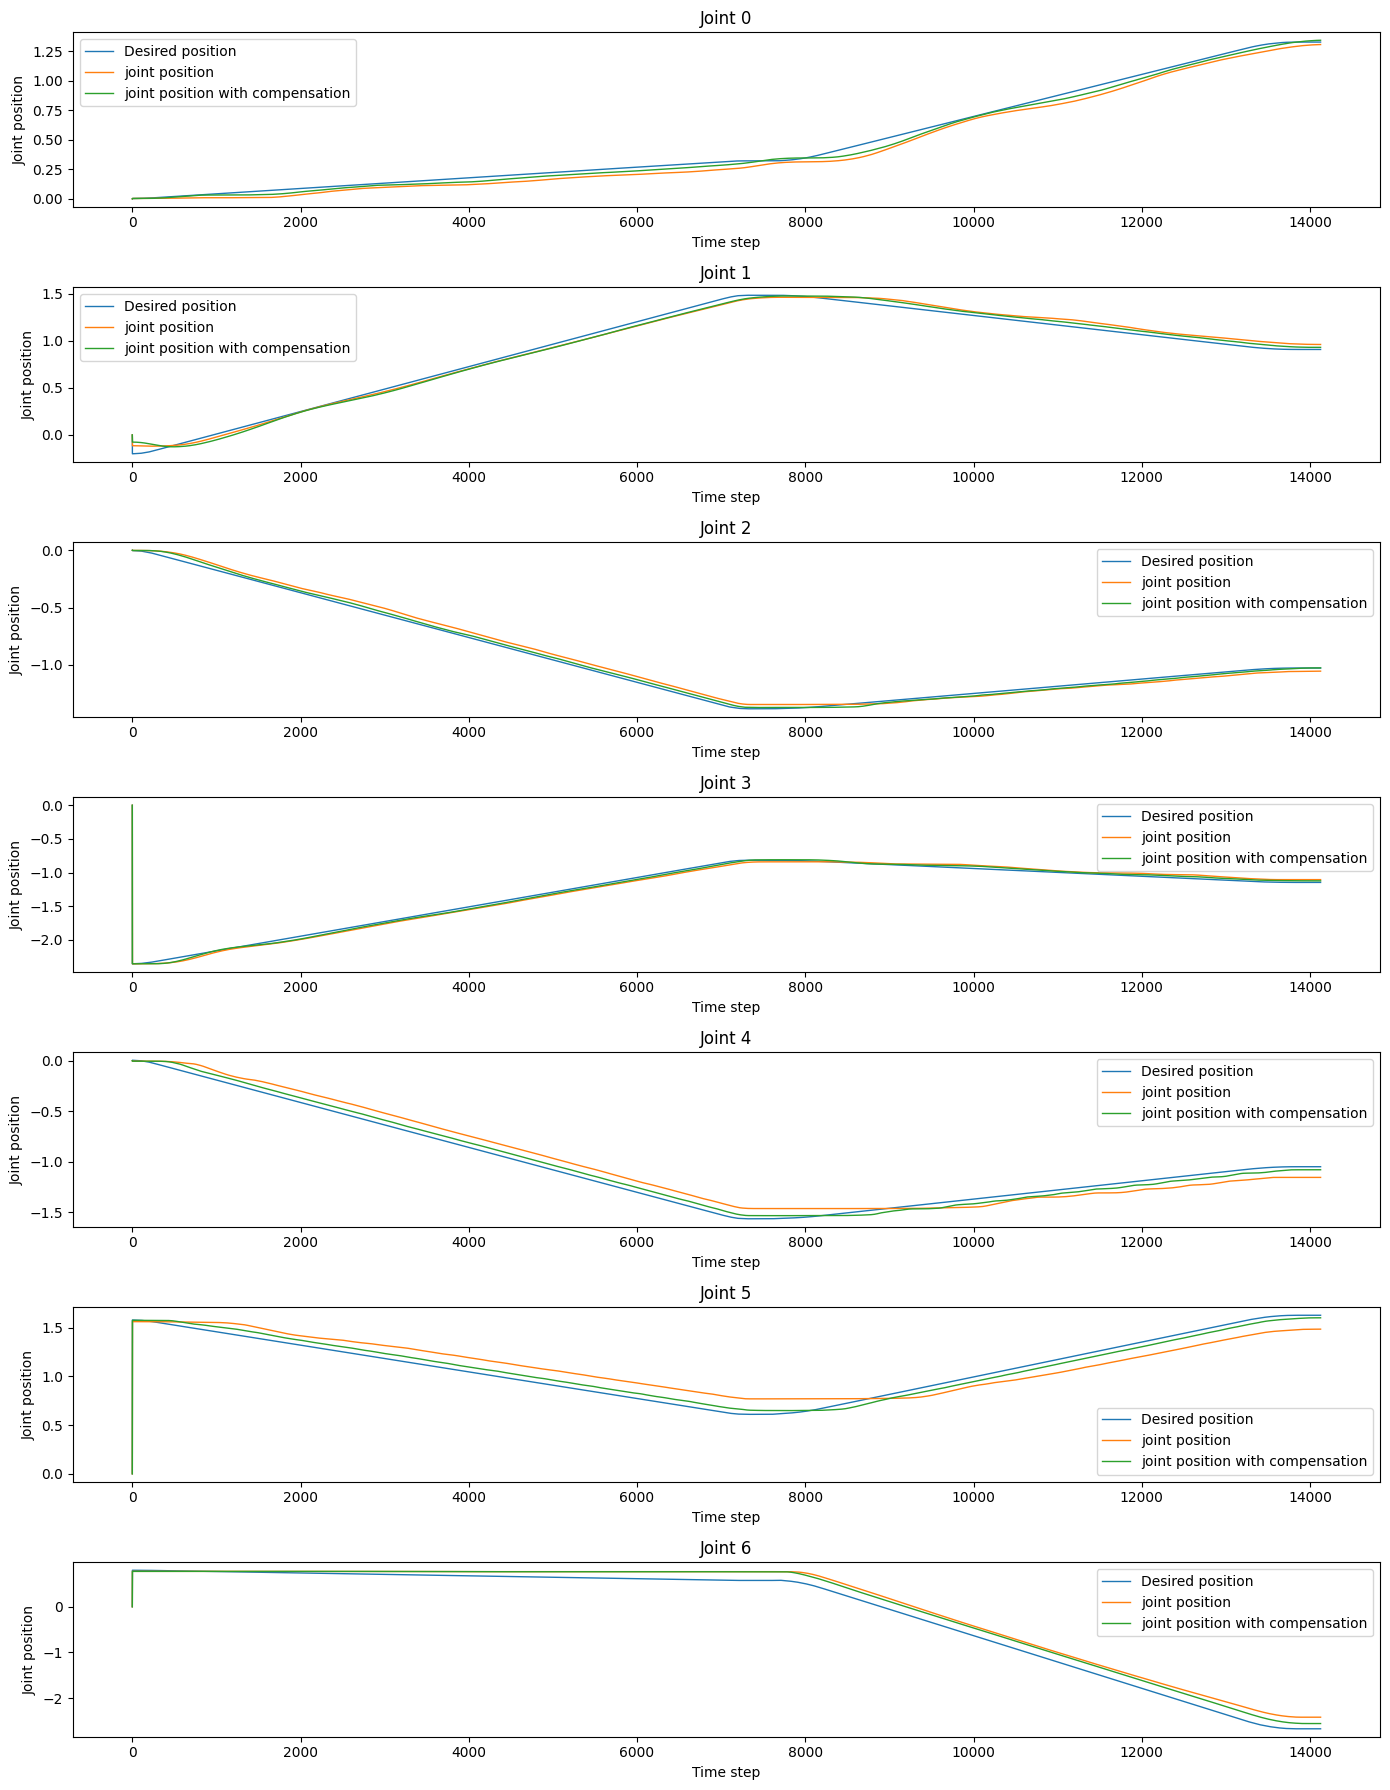

Joint 0: RMSE no-ff = 0.05555, with-ff = 0.03015
Joint 1: RMSE no-ff = 0.04592, with-ff = 0.03964
Joint 2: RMSE no-ff = 0.03999, with-ff = 0.02041
Joint 3: RMSE no-ff = 0.03884, with-ff = 0.02570
Joint 4: RMSE no-ff = 0.09524, with-ff = 0.04234
Joint 5: RMSE no-ff = 0.13042, with-ff = 0.04750
Joint 6: RMSE no-ff = 0.18007, with-ff = 0.14043


In [35]:
num_joints = tau_ext_full.shape[1]

plt.figure(figsize=(14, 18))

for i in range(num_joints):
    plt.subplot(num_joints, 1, i + 1)
    plt.plot(q_des[:, i], label="Desired position", linewidth=1.0)
    plt.plot(q_curr[:, i], label="joint position", linewidth=1.0)
    plt.plot(q_curr_kernel[:, i], label="joint position with compensation", linewidth=1.0)
    plt.title(f"Joint {i}")
    plt.xlabel("Time step")
    plt.ylabel("Joint position")
    plt.legend()

plt.tight_layout()
plt.show()

def rmse(a, b):
    err = a - b
    return np.sqrt(np.mean(err**2))

for j in range(7):
    rmse_noff = rmse(q_curr[:, j], q_des[:, j])
    rmse_ff   = rmse(q_curr_kernel[:, j],   q_des[:, j])
    print(f"Joint {j}: RMSE no-ff = {rmse_noff:.5f}, with-ff = {rmse_ff:.5f}")
